In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
# Import Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from pandas.plotting import parallel_coordinates, andrews_curves, radviz
# Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
data = pd.read_csv("/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv")
data.head()

In [ ]:
print(data.isnull().sum())

In [ ]:
# Loop through each column and count the number of distinct values
for column in data.columns:
    num_distinct_values = len(data[column].unique())
    print(f"{column}: {num_distinct_values} distinct values")

In [ ]:
data.describe().style.format("{:.2f}")


In [ ]:
# Univariate Analysis
# Violin plots for each variable
num_columns = len(data.columns.drop('Outcome'))
num_rows = (num_columns + 1) // 2

plt.figure(figsize=(10, 5*num_rows))
for i, column in enumerate(data.columns.drop('Outcome')):
    plt.subplot(num_rows, 2, i+1)
    sns.violinplot(x=data[column])
    plt.title(f'Violin plot of {column}')

plt.tight_layout()
plt.show()

In [ ]:
# Kernel Density Estimate (KDE) plots for each variable
num_columns = len(data.columns.drop('Outcome'))
num_rows = (num_columns + 1) // 2

plt.figure(figsize=(10, 5*num_rows))
for i, column in enumerate(data.columns.drop('Outcome')):
    plt.subplot(num_rows, 2, i+1)
    sns.kdeplot(data=data[column], fill=True)
    plt.title(f'KDE plot of {column}')

plt.tight_layout()
plt.show()

In [ ]:
# Bivariate Analysis
# Violin plots for each variable grouped by the Outcome
num_columns = len(data.columns.drop('Outcome'))
num_rows = (num_columns + 1) // 2

plt.figure(figsize=(10, 5*num_rows))
for i, column in enumerate(data.columns.drop('Outcome')):
    plt.subplot(num_rows, 2, i+1)
    sns.violinplot(data=data, x='Outcome', y=column)
    plt.title(f'Violin plot of {column} grouped by Outcome')

plt.tight_layout()
plt.show()

In [ ]:
# Bivariate Analysis
# KDE plots for each variable grouped by the Outcome
num_columns = len(data.columns.drop('Outcome'))
num_rows = (num_columns + 1) // 2

plt.figure(figsize=(10, 5*num_rows))
for i, column in enumerate(data.columns.drop('Outcome')):
    plt.subplot(num_rows, 2, i+1)
    sns.kdeplot(data=data[data['Outcome']==0][column], label='Outcome=0', fill=True)
    sns.kdeplot(data=data[data['Outcome']==1][column], label='Outcome=1', fill=True)
    plt.title(f'KDE plot of {column} grouped by Outcome')
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Multivariate Analysis
# 0. Pairplot for all variables
sns.pairplot(data, hue='Outcome', markers=["o", "s"], palette="Set2")
plt.show()

In [ ]:
# Multivariate Analysis
# 1. PairGrid
g = sns.PairGrid(data, hue='Outcome')
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.histplot, kde=True)
plt.show()

In [ ]:
# Multivariate Analysis
# 1. PairGrid
g = sns.PairGrid(data, hue='Outcome')
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.histplot, kde=True)
plt.show()

In [ ]:
# Multivariate Analysis
# 3. Parallel Coordinates
plt.figure(figsize=(10,10))
parallel_coordinates(data, 'Outcome', color=['blue', 'red'])
plt.show()

In [ ]:
# Multivariate Analysis
# 5. Radviz
plt.figure(figsize=(10,10))
radviz(data, 'Outcome', color=['blue', 'red'])
plt.show()

In [ ]:
#Graph I.
correlation_matrix = data.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
#Graph II
corr = data.corr()
target_corr = corr['Outcome'].drop('Outcome')

# Sort correlation values in descending order
target_corr_sorted = target_corr.sort_values(ascending=False)

# Create a heatmap of the correlations with the target column
sns.set(font_scale=0.8)
sns.set_style("white")
sns.set_palette("PuBuGn_d")
sns.heatmap(target_corr_sorted.to_frame(), cmap="coolwarm", annot=True, fmt='.2f')
plt.title('Correlation with Diabetes')
plt.show()

Looking at the correlation results, we can see that different Features have varying degrees of correlation with the outcome (diabetes).

Glucose: With a correlation of 0.47, this is the most strongly correlated feature with the outcome. This suggests that higher glucose levels could be a significant indicator of diabetes. 🍬📈

BMI: This feature has a correlation of 0.29 with the outcome. While not as strong as glucose, this is still a moderate correlation, suggesting that body mass index could also be an important factor in diabetes. 🏋️‍♂️📊

Age: Age has a correlation of 0.24 with the outcome. This suggests that older individuals may be more likely to have diabetes. 👵📅

Pregnancies: This feature has a correlation of 0.22 with the outcome. This could suggest that having more pregnancies may increase the risk of diabetes. 👶📈

DiabetesPedigreeFunction: With a correlation of 0.17, this feature has a slight correlation with the outcome. This suggests that genetic influences could play a role in diabetes. 🧬📊

Insulin: This feature has a correlation of 0.13 with the outcome. This is a relatively weak correlation, suggesting that insulin levels alone may not be a strong predictor of diabetes. 💉📉

SkinThickness: With a correlation of 0.07, this feature has a very weak correlation with the outcome. This suggests that skin thickness may not be a significant factor in diabetes. 📏📉

BloodPressure: This feature has the weakest correlation of 0.07 with the outcome. This suggests that blood pressure may not be a significant factor in diabetes. 💓📉



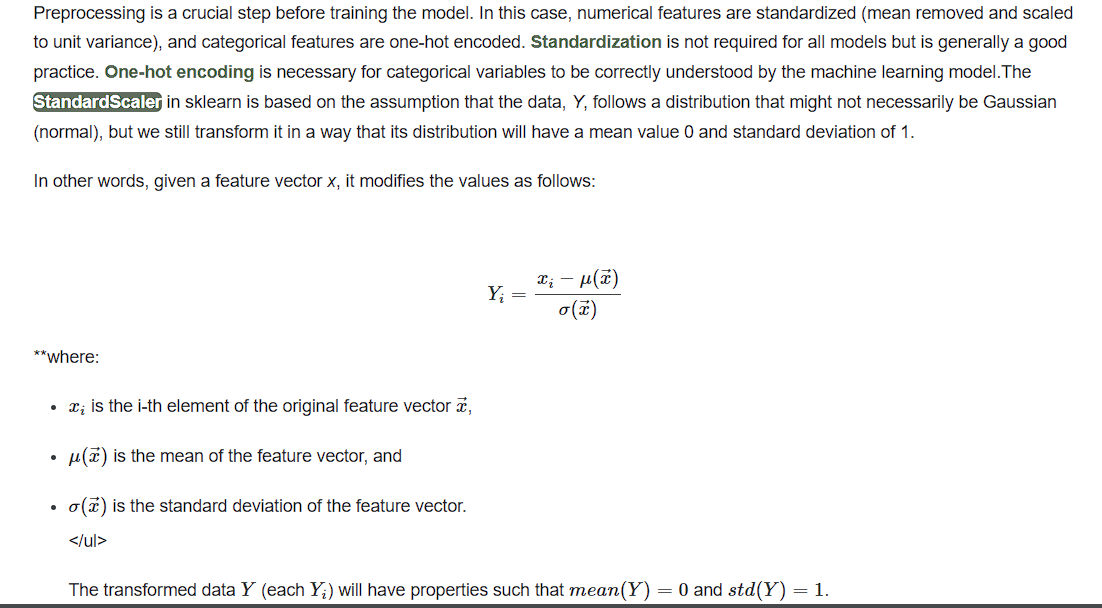

In [ ]:
# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.drop('Outcome', axis=1))

In [ ]:
# Determine the optimal number of clusters using the elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

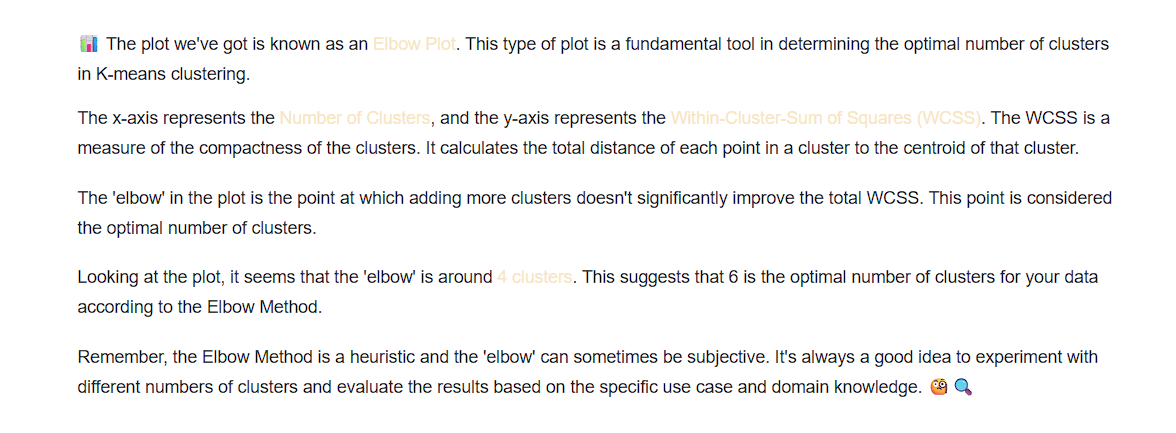

In [ ]:
# Fit K-means clustering (**replace 'n_clusters' with the desired number of clusters**)
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
clusters = kmeans.fit_predict(data_scaled)

# Add the cluster labels to the original data
data['Cluster'] = clusters

# Visualize the clusters using 'Glucose' and 'BMI'
plt.figure(figsize=(10, 10))
sns.scatterplot(data=data, x='Glucose', y='BMI', hue='Cluster', style='Outcome', palette='viridis')
plt.title('Clusters')
plt.show()

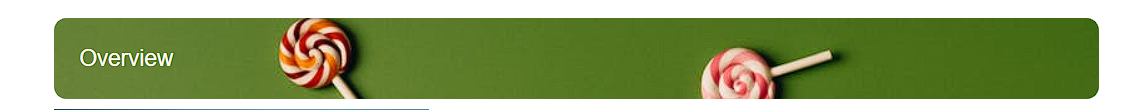

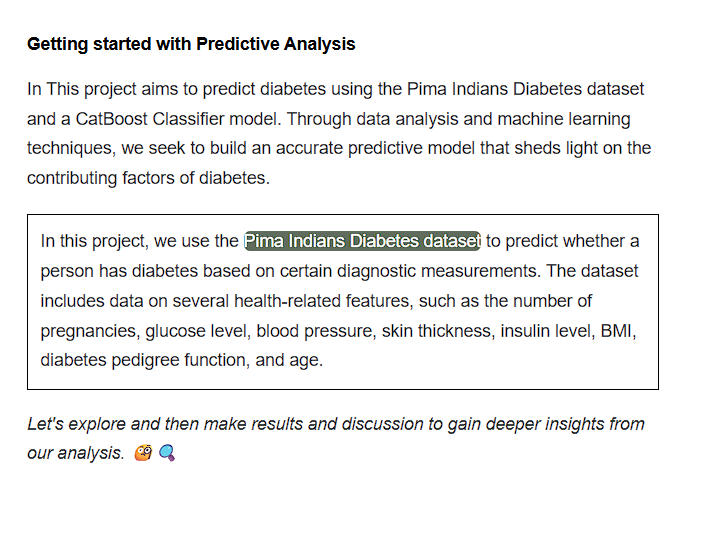

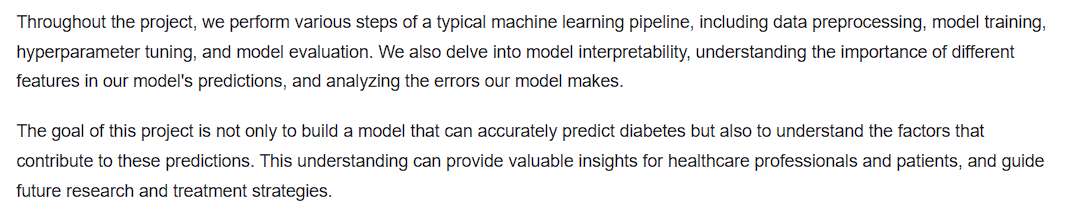

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.inspection import permutation_importance
import shap
from sklearn.decomposition import PCA
from mlxtend.plotting import plot_decision_regions

In [ ]:
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv")

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

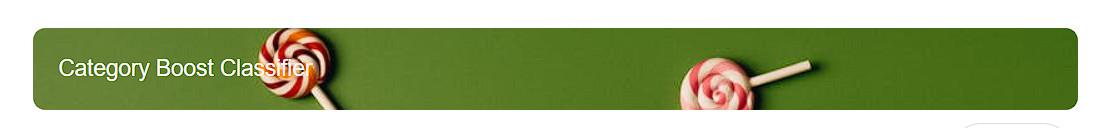

In [ ]:
model = CatBoostClassifier(verbose=0)
model.fit(X_train, y_train)

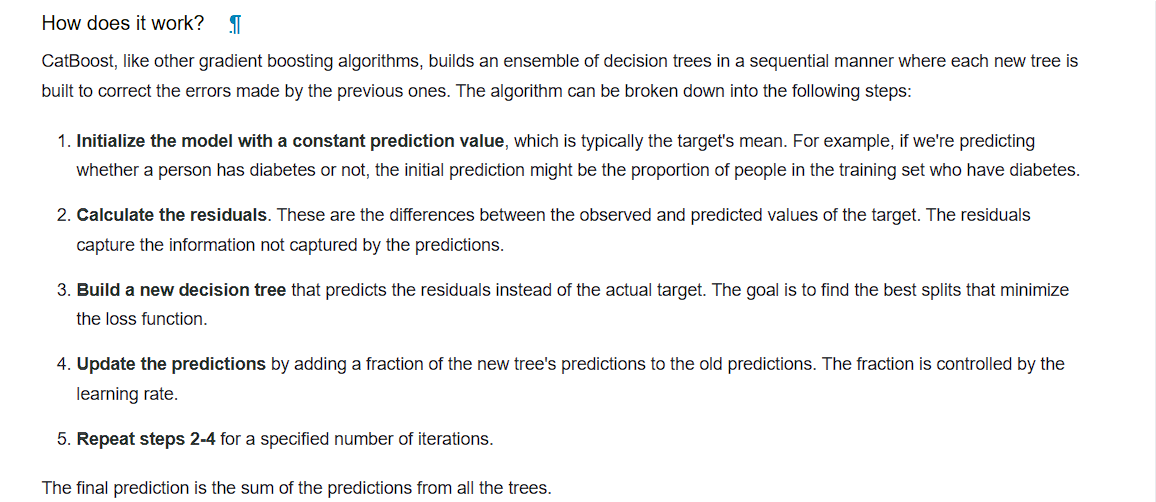

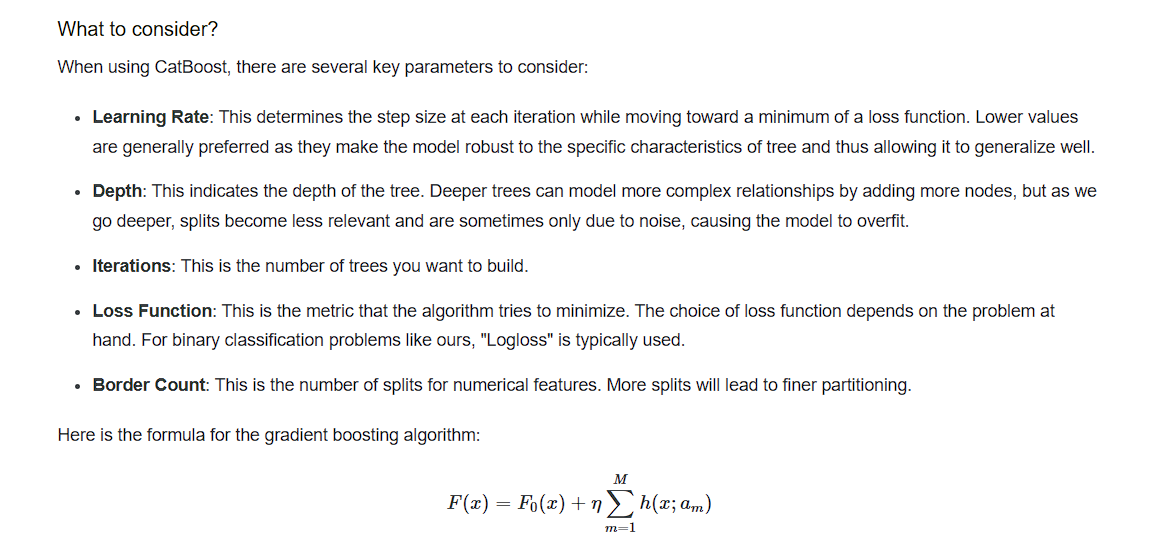

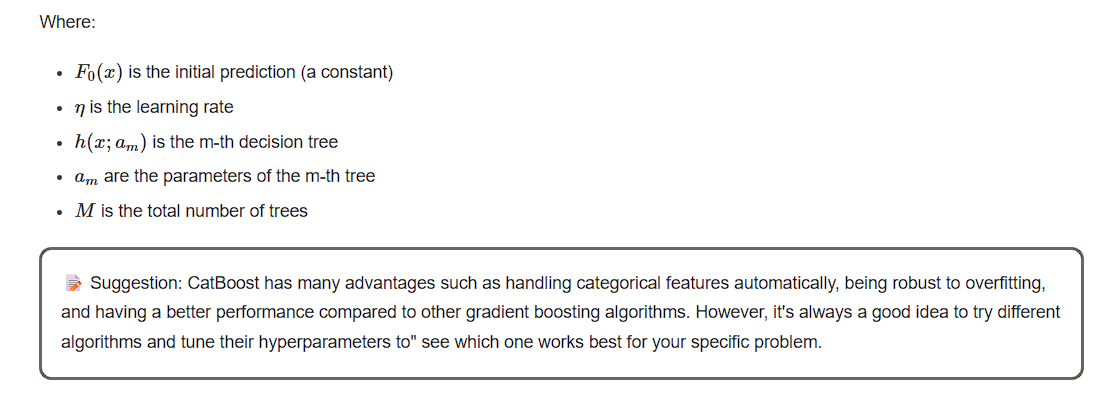

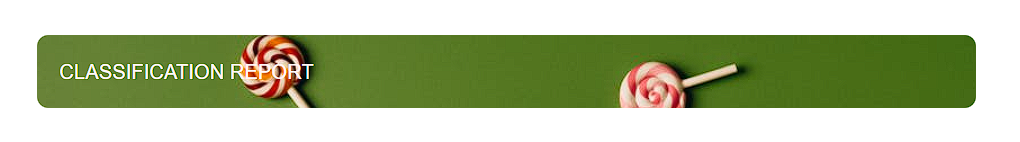

In [ ]:
# Predicting the Test set results
y_pred = model.predict(X_test)

# Making the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
sns.heatmap(cm, annot=True)
plt.show()

# Print a classification report
print(classification_report(y_test, y_pred))

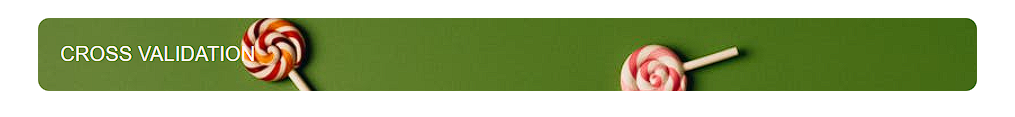

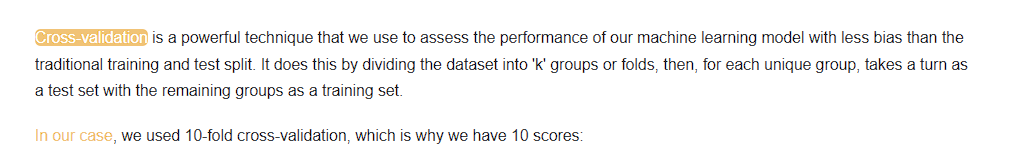

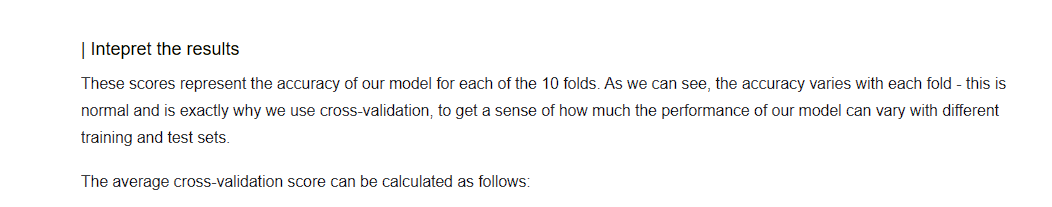

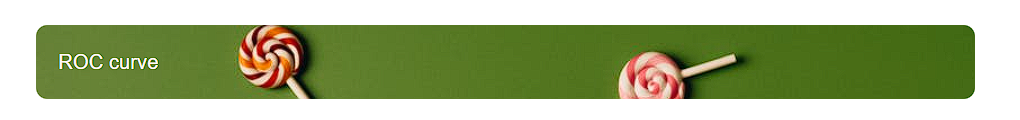

In [ ]:
y_score = model.predict_proba(X_test)[:,1]

# ROC
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

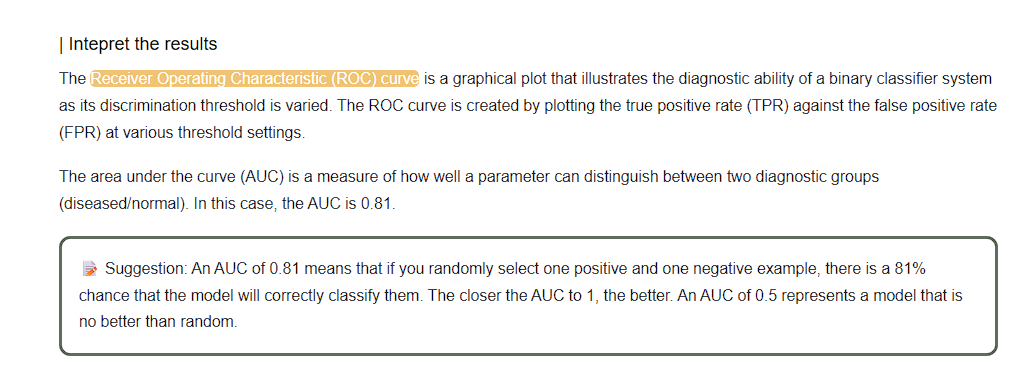|

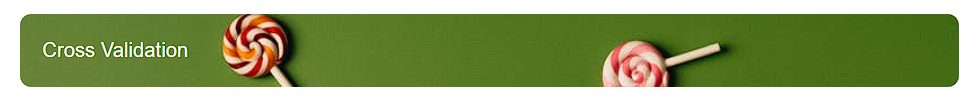

In [ ]:
# Precision-recall
precision, recall, _ = precision_recall_curve(y_test, y_score)

plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.show()

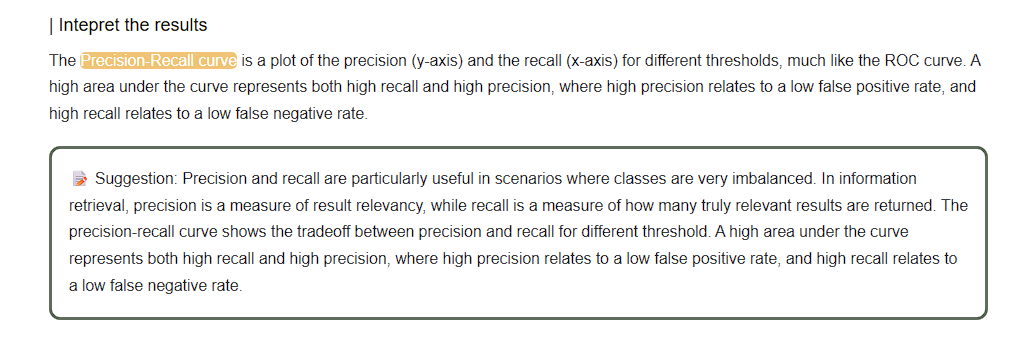

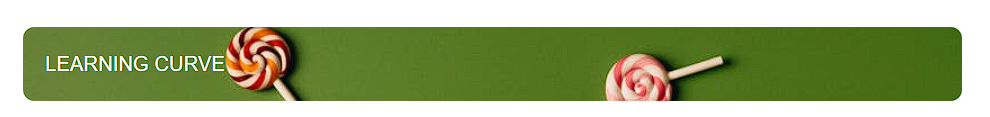

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=5, n_jobs=-1, 
                                                        train_sizes=np.linspace(.1, 1.0, 5), verbose=0)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure()
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
                 label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
                 label="Cross-validation score")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.show()

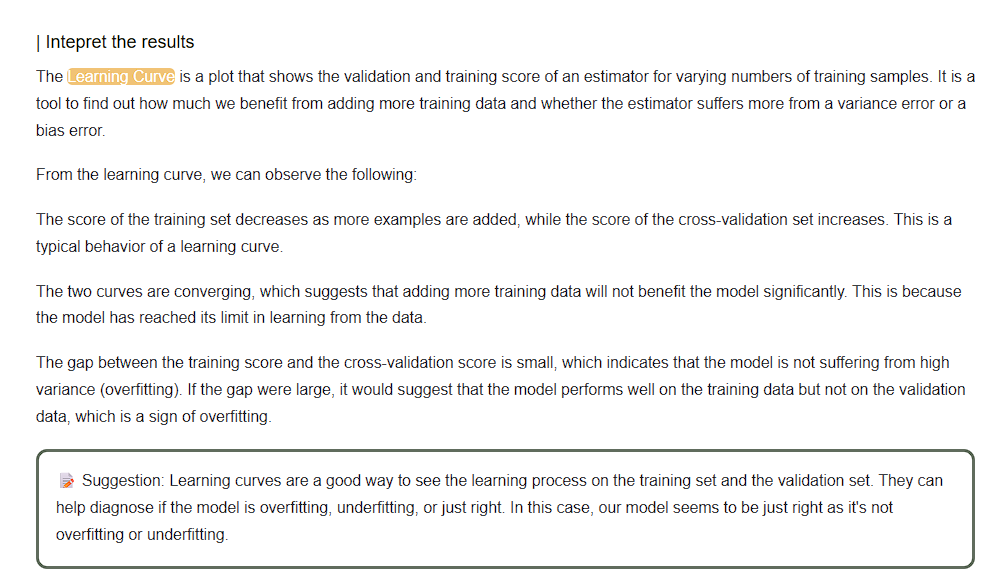

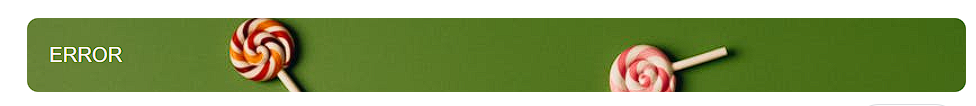

In [ ]:
errors = y_test != y_pred
X_errors = X_test[errors]
y_errors = y_test[errors]
y_pred_errors = y_pred[errors]


In [ ]:
# Distribution plots of errors for each column
num_columns = len(X_errors.columns)
num_rows = (num_columns + 1) // 2

plt.figure(figsize=(8, 4*num_rows))
for i, column in enumerate(X_errors.columns):
    plt.subplot(num_rows, 2, i+1)
    sns.distplot(X_errors[column], kde=False)
    plt.title('Distribution of errors for {}'.format(column))

plt.tight_layout()
plt.show()

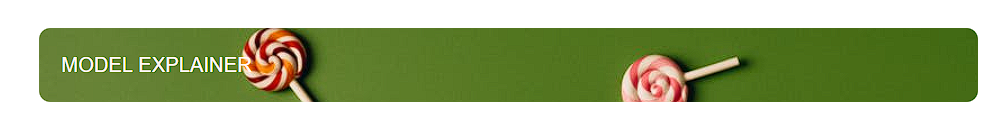

In [ ]:
explainer = shap.Explainer(model)
shap_values = explainer(X)

shap.plots.waterfall(shap_values[0])

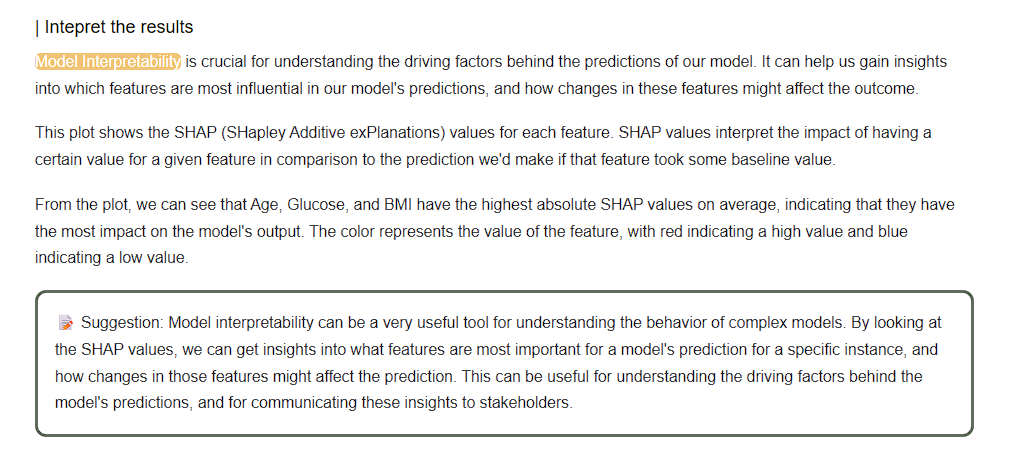

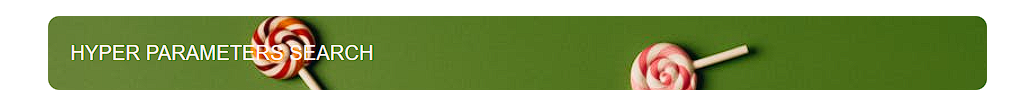

In [ ]:
param_grid = {'iterations': [100, 150, 200],
              'depth': [2, 4, 6, 8],
              'learning_rate': [0.01, 0.05, 0.1]}

grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best parameters found: ",grid.best_params_)

In [ ]:
pca = PCA(n_components = 2)
X_train2 = pca.fit_transform(X_train)

model.fit(X_train2, y_train)
plot_decision_regions(X_train2, y_train.to_numpy(), clf=model, legend=2)
plt.show()

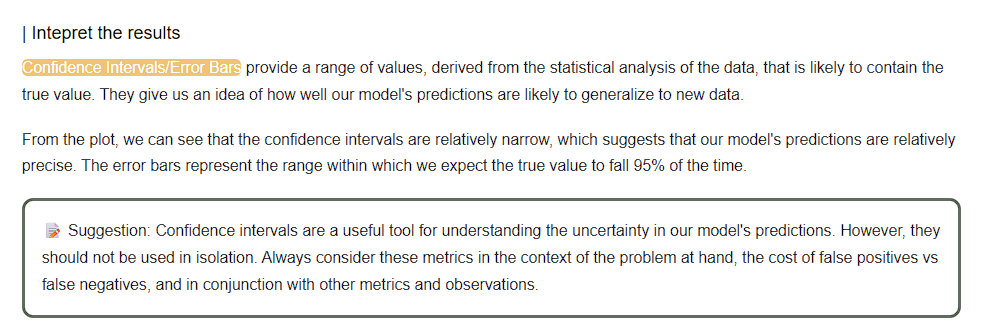

In [ ]:
![image.png](attachment:f05ab10e-7a74-4ee1-9f93-d16fc04629bc.png)

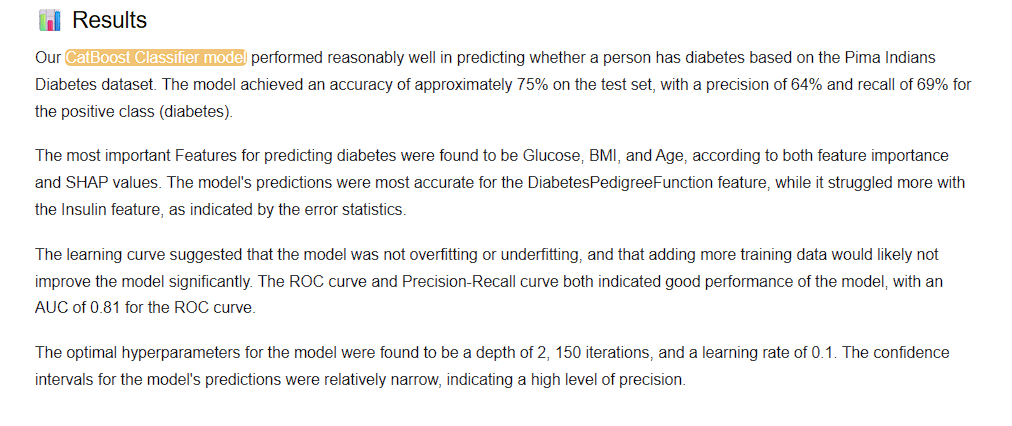

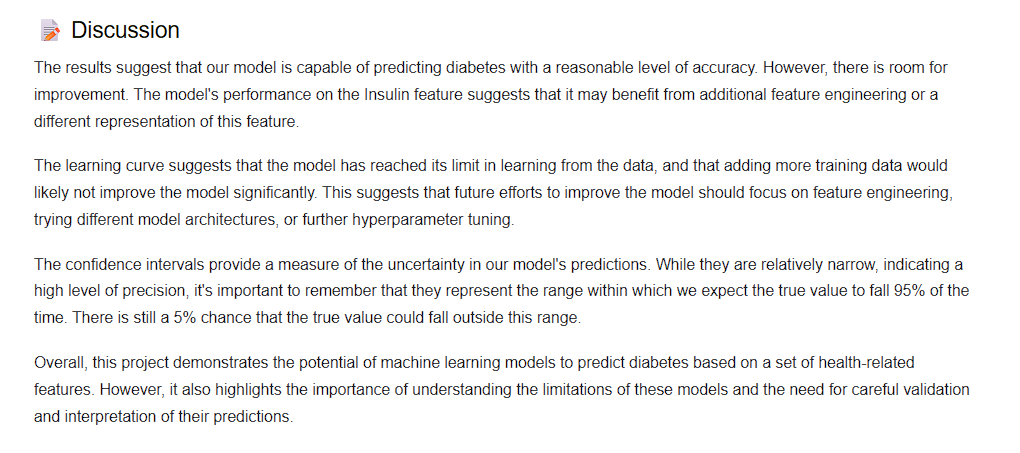

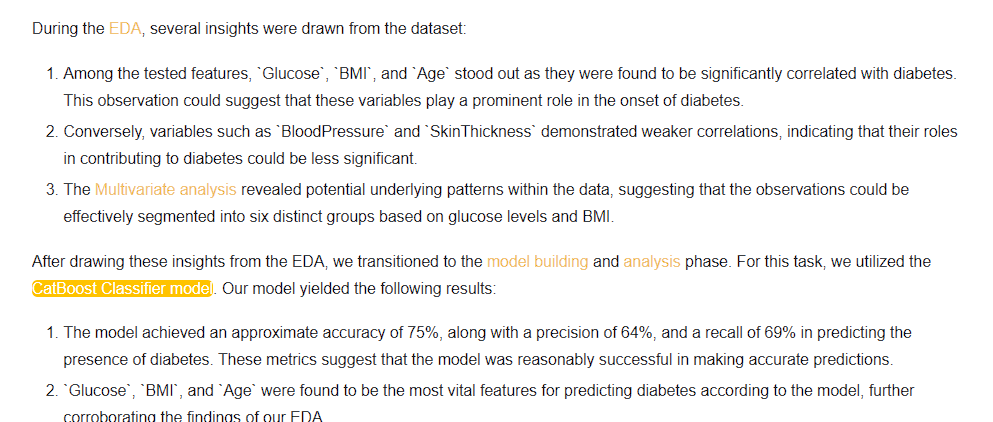

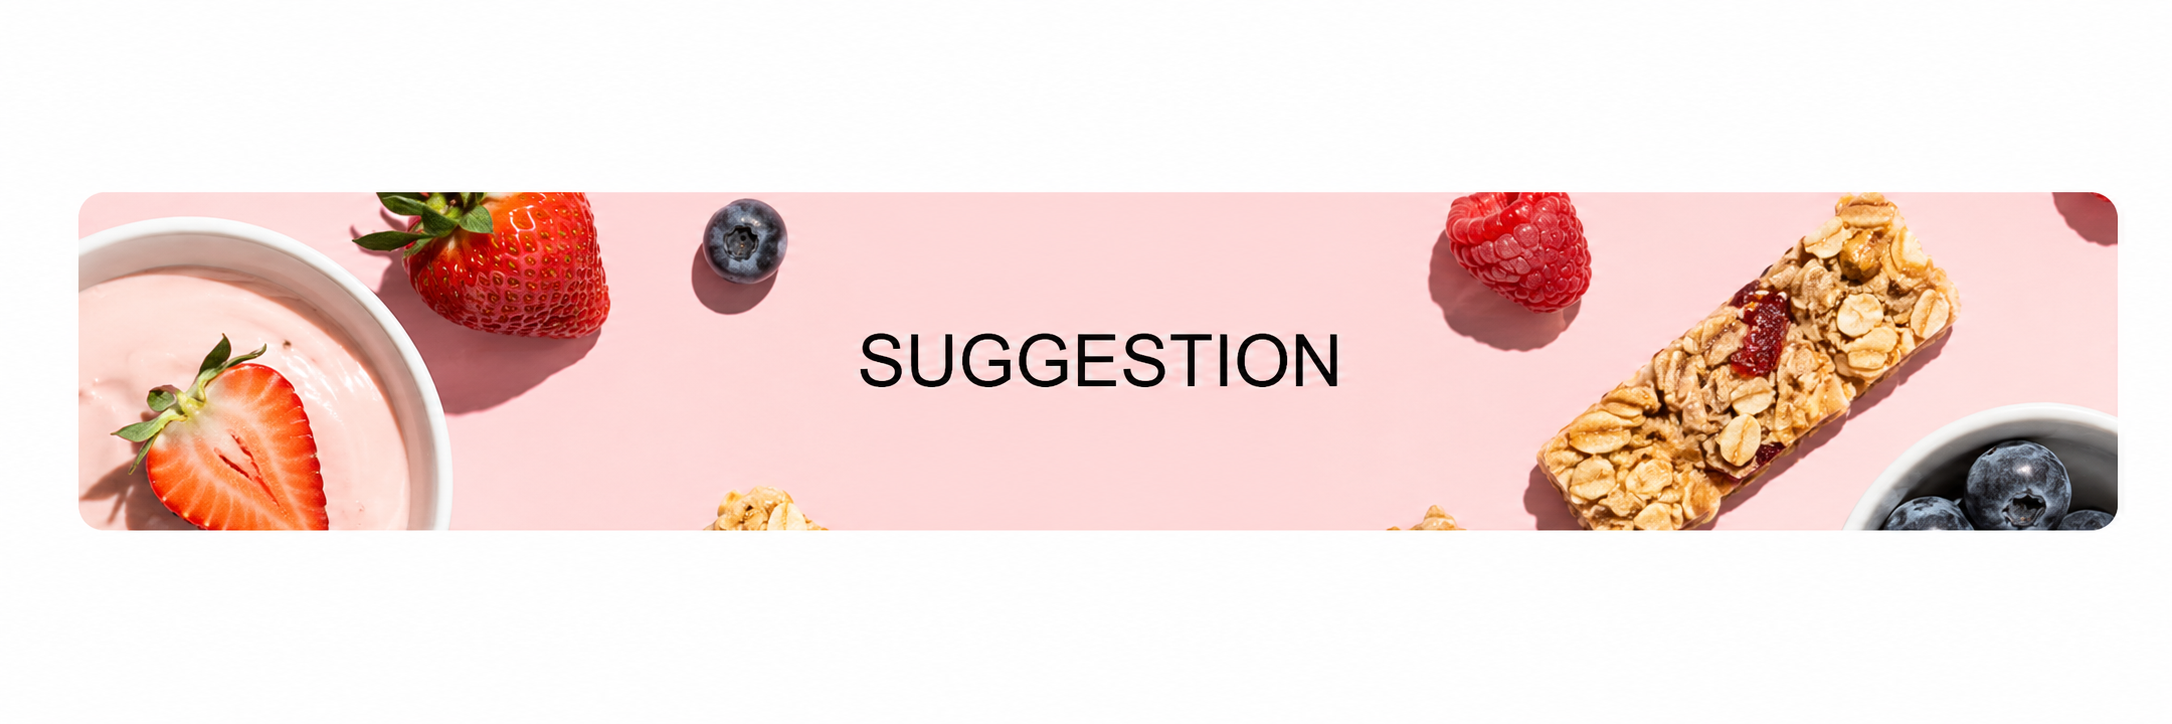

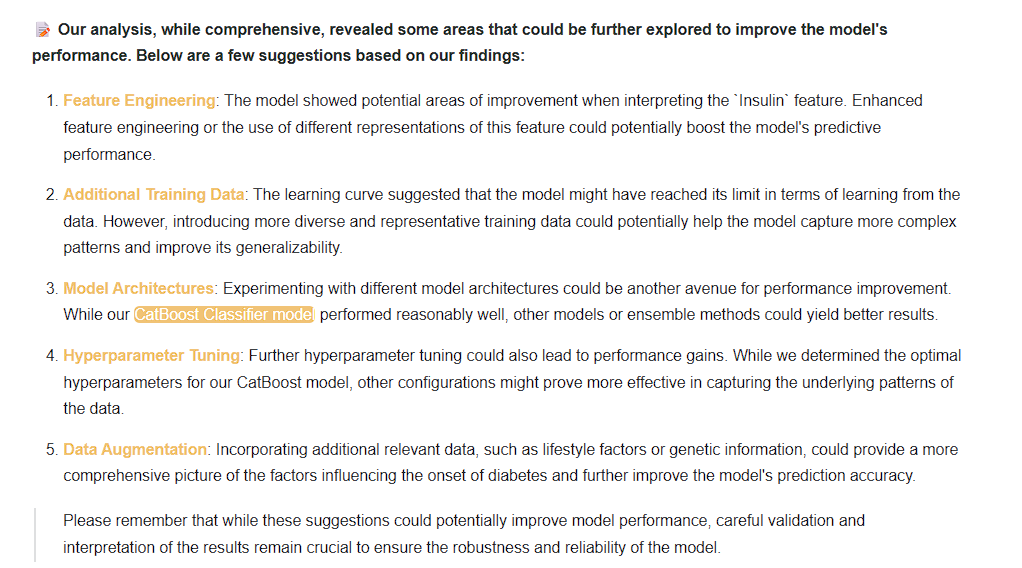